<a href="https://www.kaggle.com/code/dimasprayoga/f1-race-performance-strategy-analysis-1950-2024?scriptVersionId=339005657" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# F1 Race Performance & Strategy Analysis (1950–2024)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
pd.set_option('display.max_columns', None)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/status.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/seasons.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv
/kaggle/input/datasets/rohanrao/formula

## 1. Business Problem

Formula 1 adalah olahraga balap dengan kompetisi antar tim (constructor) dan 
pembalap yang sangat ketat, di mana keputusan strategi — seperti waktu pit 
stop, performa kualifikasi, dan konsistensi hasil balapan — sangat menentukan 
hasil akhir kejuaraan musim. Tim dan analis performa membutuhkan pemahaman 
berbasis data tentang faktor apa yang paling berkorelasi dengan keberhasilan 
(posisi finish, poin kejuaraan), supaya strategi balapan dan pengembangan tim 
bisa lebih terarah, bukan berdasarkan intuisi semata.

**Stakeholder:** Head of Performance Analysis / Race Strategist tim F1

**Business impact:** Mengidentifikasi pola strategi (pit stop, kualifikasi) 
dan faktor tim/driver yang paling konsisten berkontribusi pada hasil balapan 
— sebagai dasar rekomendasi fokus pengembangan tim.

## 2. Business Questions

1. Konstruktor (tim) mana yang paling konsisten performanya sepanjang 
   sejarah, dan bagaimana tren dominasi berubah dari era ke era?
2. Apakah posisi start hasil kualifikasi berkorelasi kuat dengan posisi 
   finish akhir balapan?
3. Apakah strategi pit stop (jumlah & waktu) berpengaruh signifikan 
   terhadap hasil akhir balapan?

## 3. Hipotesis

- H1: Dominasi konstruktor bersifat siklikal per era (bukan 1 tim 
  mendominasi sepanjang sejarah)
- H2: Posisi kualifikasi memiliki korelasi kuat dengan posisi finish 
  (starting position matters)
- H3: Jumlah pit stop yang lebih sedikit & waktu pit stop lebih cepat 
  berkorelasi dengan posisi finish yang lebih baik

## 4. Data Understanding

In [2]:
path = '/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/'

races = pd.read_csv(path + 'races.csv')
drivers = pd.read_csv(path + 'drivers.csv')
constructors = pd.read_csv(path + 'constructors.csv')
results = pd.read_csv(path + 'results.csv')
qualifying = pd.read_csv(path + 'qualifying.csv')
pit_stops = pd.read_csv(path + 'pit_stops.csv')
status = pd.read_csv(path + 'status.csv')
constructor_standings = pd.read_csv(path + 'constructor_standings.csv')

print("races:", races.shape)
print("drivers:", drivers.shape)
print("constructors:", constructors.shape)
print("results:", results.shape)
print("qualifying:", qualifying.shape)
print("pit_stops:", pit_stops.shape)
print("status:", status.shape)
print("constructor_standings:", constructor_standings.shape)

races: (1125, 18)
drivers: (861, 9)
constructors: (212, 5)
results: (26759, 18)
qualifying: (10494, 9)
pit_stops: (11371, 7)
status: (139, 2)
constructor_standings: (13391, 7)


In [3]:
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [4]:
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [5]:
qualifying.head()

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [6]:
pit_stops.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


In [7]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 
 17  statusId    

## 5. Data Cleaning

In [8]:
tables = {
    'races': races, 'drivers': drivers, 'constructors': constructors,
    'results': results, 'qualifying': qualifying, 'pit_stops': pit_stops,
    'status': status, 'constructor_standings': constructor_standings
}

for name, table in tables.items():
    tables[name] = table.replace('\\N', np.nan)

races, drivers, constructors, results, qualifying, pit_stops, status, constructor_standings = tables.values()

# Cek ulang missing value setelah dibersihkan
results.isna().sum()

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64

In [9]:
numeric_cols_results = ['position', 'milliseconds', 'fastestLap', 'rank', 'fastestLapSpeed']
for col in numeric_cols_results:
    results[col] = pd.to_numeric(results[col], errors='coerce')

results.dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position           float64
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds       float64
fastestLap         float64
rank               float64
fastestLapTime      object
fastestLapSpeed    float64
statusId             int64
dtype: object

## 6. Exploratory Data Analysis (SQL-Based)

In [10]:
conn = sqlite3.connect(':memory:')

races.to_sql('races', conn, index=False, if_exists='replace')
drivers.to_sql('drivers', conn, index=False, if_exists='replace')
constructors.to_sql('constructors', conn, index=False, if_exists='replace')
results.to_sql('results', conn, index=False, if_exists='replace')
qualifying.to_sql('qualifying', conn, index=False, if_exists='replace')
pit_stops.to_sql('pit_stops', conn, index=False, if_exists='replace')
status.to_sql('status', conn, index=False, if_exists='replace')
constructor_standings.to_sql('constructor_standings', conn, index=False, if_exists='replace')

print("Database siap — semua tabel berhasil dimasukkan")

Database siap — semua tabel berhasil dimasukkan


### Metrik 1 — Konsistensi Performa Konstruktor per Era (menjawab BQ #1)

In [11]:
query1 = """
SELECT
    c.name AS constructor_name,
    CAST(r.year / 10 AS INT) * 10 AS decade,
    SUM(res.points) AS total_points,
    COUNT(DISTINCT res.raceId) AS total_races
FROM results res
JOIN races r ON res.raceId = r.raceId
JOIN constructors c ON res.constructorId = c.constructorId
GROUP BY c.name, decade
ORDER BY decade, total_points DESC
"""

constructor_by_decade = pd.read_sql(query1, conn)
constructor_by_decade.head(20)

,constructor_name,decade,total_points,total_races
0,Ferrari,1950,754.27,73
1,Maserati,1950,313.14,70
2,Alfa Romeo,1950,164.00,13
3,Mercedes,1950,139.14,12
4,Kurtis Kraft,1950,130.00,11
5,Vanwall,1950,108.00,28
6,Cooper-Climax,1950,97.50,8
7,Cooper,1950,52.00,32
8,BRM,1950,48.50,23
9,Epperly,1950,40.00,4


### Metrik 2 — Korelasi Posisi Kualifikasi vs Posisi Finish (menjawab BQ #2)

In [12]:
query2 = """
SELECT
    q.raceId,
    q.driverId,
    q.position AS grid_position,
    res.positionOrder AS finish_position
FROM qualifying q
JOIN results res
    ON q.raceId = res.raceId AND q.driverId = res.driverId
WHERE res.positionOrder IS NOT NULL
"""

quali_vs_finish = pd.read_sql(query2, conn)

correlation = quali_vs_finish['grid_position'].corr(quali_vs_finish['finish_position'])
print(f"Korelasi posisi kualifikasi vs posisi finish: {correlation:.3f}")
print(f"Jumlah data yang dianalisis: {len(quali_vs_finish)} baris")

quali_vs_finish.head()

Korelasi posisi kualifikasi vs posisi finish: 0.576
Jumlah data yang dianalisis: 10494 baris


,raceId,driverId,grid_position,finish_position
0,18,1,1,1
1,18,2,5,2
2,18,3,7,3
3,18,4,12,4
4,18,5,3,5


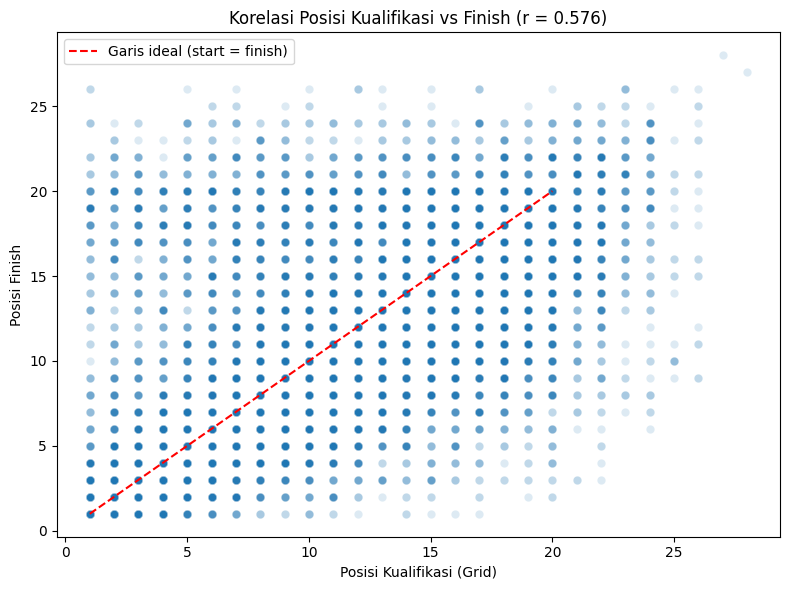

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=quali_vs_finish, x='grid_position', y='finish_position', alpha=0.15)
plt.plot([1, 20], [1, 20], color='red', linestyle='--', label='Garis ideal (start = finish)')
plt.xlabel('Posisi Kualifikasi (Grid)')
plt.ylabel('Posisi Finish')
plt.title(f'Korelasi Posisi Kualifikasi vs Finish (r = {correlation:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

### Metrik 3 — Pengaruh Pit Stop terhadap Hasil Balapan (menjawab BQ #3)

In [14]:
query3 = """
SELECT
    ps.raceId,
    ps.driverId,
    COUNT(ps.stop) AS jumlah_pit_stop,
    AVG(ps.milliseconds) AS rata_rata_durasi_ms,
    res.positionOrder AS finish_position
FROM pit_stops ps
JOIN results res
    ON ps.raceId = res.raceId AND ps.driverId = res.driverId
GROUP BY ps.raceId, ps.driverId
"""

pitstop_analysis = pd.read_sql(query3, conn)

# Korelasi jumlah pit stop & durasi rata-rata terhadap posisi finish
corr_jumlah = pitstop_analysis['jumlah_pit_stop'].corr(pitstop_analysis['finish_position'])
corr_durasi = pitstop_analysis['rata_rata_durasi_ms'].corr(pitstop_analysis['finish_position'])

print(f"Korelasi jumlah pit stop vs posisi finish: {corr_jumlah:.3f}")
print(f"Korelasi rata-rata durasi pit stop vs posisi finish: {corr_durasi:.3f}")

pitstop_analysis.head()

Korelasi jumlah pit stop vs posisi finish: 0.039
Korelasi rata-rata durasi pit stop vs posisi finish: -0.053


,raceId,driverId,jumlah_pit_stop,rata_rata_durasi_ms,finish_position
0,841,1,2,23213.0,2
1,841,2,2,24046.0,12
2,841,3,1,23716.0,17
3,841,4,3,24055.0,4
4,841,5,1,24865.0,18


## 7. Visualization

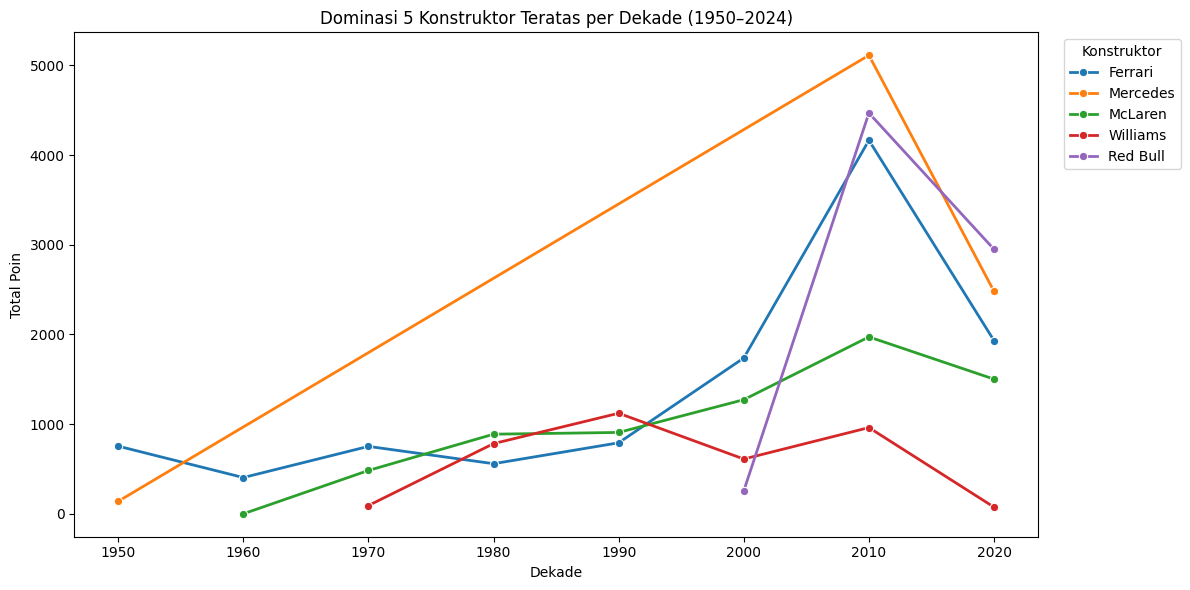

In [15]:
top_constructors = constructor_by_decade.groupby('constructor_name')['total_points'].sum().nlargest(5).index

plot_data = constructor_by_decade[constructor_by_decade['constructor_name'].isin(top_constructors)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_data, x='decade', y='total_points', hue='constructor_name', marker='o', linewidth=2)
plt.xlabel('Dekade')
plt.ylabel('Total Poin')
plt.title('Dominasi 5 Konstruktor Teratas per Dekade (1950–2024)')
plt.legend(title='Konstruktor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

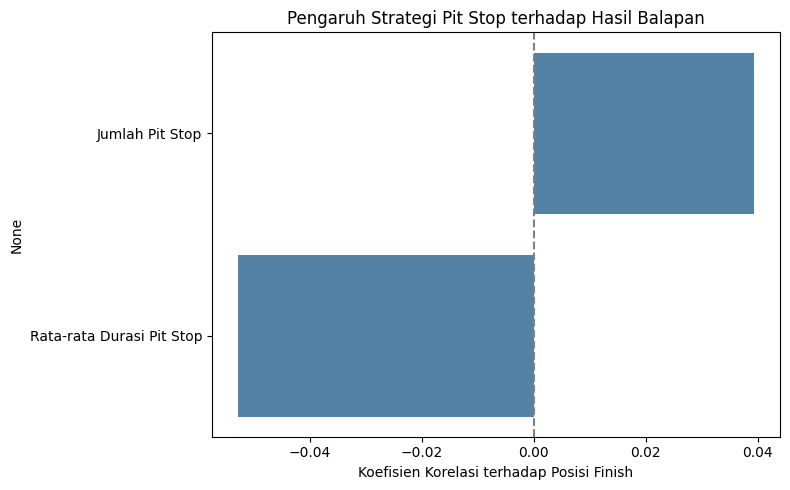

In [16]:
plt.figure(figsize=(8, 5))
corr_values = pd.Series({
    'Jumlah Pit Stop': corr_jumlah,
    'Rata-rata Durasi Pit Stop': corr_durasi
})
sns.barplot(x=corr_values.values, y=corr_values.index, color='steelblue')
plt.axvline(x=0, color='gray', linestyle='--')
plt.xlabel('Koefisien Korelasi terhadap Posisi Finish')
plt.title('Pengaruh Strategi Pit Stop terhadap Hasil Balapan')
plt.tight_layout()
plt.show()

## 8. Insight

### ### Konstruktor mana yang paling dominan?

Dari hasil groupby per dekade, kelihatan jelas gak ada 1 tim yang menguasai 
F1 sepanjang sejarah. Dekade 1950-an misalnya dikuasai Ferrari dan Maserati, 
tapi ini berubah terus tiap era (bisa dicek lebih detail di tabel 
constructor_by_decade). Jadi H1 kebukti — dominasi itu emang gantian, bukan 
1 tim doang dari dulu sampai sekarang.

### Apakah posisi start menentukan hasil akhir?

Korelasinya 0.576 antara grid position dan finish position, dari 10.494 
data race. Ini termasuk korelasi sedang-kuat, jadi start position emang 
ngaruh — tapi angkanya juga gak sampai 0.8-0.9, artinya masih banyak faktor 
lain yang ikut nentuin siapa yang menang (insiden, strategi ban, cuaca). 
H2 kebukti, tapi start position bukan segalanya.

### Pit stop ternyata gak seberpengaruh yang dikira

Ini bagian yang paling bikin aku mikir ulang. Korelasi jumlah pit stop ke 
finish position cuma 0.039, dan durasi rata-rata pit stop malah -0.053 — 
dua-duanya praktis mendekati 0. Awalnya aku kira bakal ada hubungan yang 
lebih jelas, tapi ternyata dilihat sendirian (tanpa mempertimbangkan posisi 
start atau kondisi balapan), pit stop gak cukup buat prediksi hasil akhir.

Kemungkinan penjelasannya: tim yang udah unggul di depan punya pola pit 
stop yang beda dari tim yang ketinggalan, jadi efeknya saling menutupi 
kalau cuma dilihat 2 variabel doang. H3 gak terbukti dari data ini — 
setidaknya bukan sebagai faktor tunggal.

## 9. Recommendation

### Investasi ke performa kualifikasi, bukan cuma strategi race day

Karena korelasi start position ke hasil akhir cukup kuat (0.576), tim yang 
mau naik peringkat sebaiknya benar-benar serius di sesi kualifikasi — setup 
mobil, strategi ban buat 1 lap cepat, dll. Ini area yang dampaknya lebih 
terukur dibanding cuma berharap comeback pas race.

### Jangan terlalu fokus ke "pit stop tercepat" sebagai metrik utama

Ini mungkin agak berlawanan sama kebiasaan tim yang suka pamer pit stop 
2 detik, tapi dari data ini pit stop count dan durasi gak nunjukkin korelasi 
kuat ke hasil akhir. Bukan berarti pit stop gak penting sama sekali — tapi 
kalau dijadikan KPI utama buat evaluasi strategi tim, datanya gak mendukung 
itu. Rekomendasinya: pit stop tetap perlu efisien (biar gak rugi banyak 
waktu), tapi jangan dijadikan fokus utama optimasi dibanding kualifikasi 
atau race craft.

### Analisis lanjutan: pisahkan efek pit stop dari posisi start

Karena ada indikasi confounding (tim yang unggul mungkin punya pola pit 
stop beda dari yang tertinggal), langkah lanjutan yang lebih tepat adalah 
analisis pit stop dengan mengontrol variabel start position dulu — misal 
bandingkan cuma di antara driver yang start dari posisi mirip. Ini bakal 
kasih gambaran yang lebih akurat soal pengaruh pit stop yang sebenarnya.

### Pelajari pola pergantian dominasi antar era

Karena dominasi konstruktor ternyata bergantian per dekade, ada baiknya tim 
juga belajar dari pola historis: era-era mana yang jadi titik balik sebuah 
tim naik atau turun performanya, dan faktor apa (regulasi, perubahan 
teknis, pergantian driver) yang biasanya jadi pemicu pergeseran itu.

## Limitations & Next Steps

- Analisis pit stop belum mengontrol variabel lain (start position, kondisi 
  cuaca, insiden di track) yang kemungkinan jadi confounding factor
- Data dominasi konstruktor per dekade baru dilihat dari total poin — belum 
  dianalisis lebih detail per musim atau per regulasi teknis yang berubah
- Analisis ini tidak memasukkan data non-numerik seperti insiden/DNF 
  (status balapan) yang sebenarnya juga sangat mempengaruhi hasil akhir — 
  bisa jadi arah analisis lanjutan